## Assignment ann cnn - part2

## Accident Detection From CCTV Footage


## Prepared by Yogesh singh batch 13

## Import libraries

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2

## kaggle file upload

In [12]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yogeshrana12","key":"3676b20709e1b078c2fcf48b3f85a997"}'}

## kaggle api set up

for directly download data from kaggle

In [13]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

## Dataset download

download the dataset from kagggle jason api key , contain cctv footage for accident dettection which used for dl model training and prediction

In [14]:
!kaggle datasets download -d ckay16/accident-detection-from-cctv-footage

Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
License(s): ODbL-1.0
100% 249M/249M [00:02<00:00, 100MB/s] 



## dataset extraction

unzip the zip file

In [15]:
import zipfile
with zipfile.ZipFile('accident-detection-from-cctv-footage.zip', 'r') as zip_ref:
    zip_ref.extractall('accident_dataset')

## viw the dataset

use to display the file content available in dataset

In [16]:
import os

os.listdir('accident_dataset')

['data']

## explore the datset strucure

use to  display the all content and path inside the accident dataset

In [17]:
base_path = 'accident_dataset'

for root, dirs, files in os.walk(base_path):
    print(root)

accident_dataset
accident_dataset/data
accident_dataset/data/test
accident_dataset/data/test/Non Accident
accident_dataset/data/test/Accident
accident_dataset/data/train
accident_dataset/data/train/Non Accident
accident_dataset/data/train/Accident
accident_dataset/data/val
accident_dataset/data/val/Non Accident
accident_dataset/data/val/Accident


## Define dataset path

for train ,test , validate

In [18]:
import os

train_path = 'accident_dataset/data/train'
val_path = 'accident_dataset/data/val'
test_path = 'accident_dataset/data/test'



# display dataset clssess avail within



In [19]:
print('Train Classes :',os.listdir(train_path))
print('Validation Classes :',os.listdir(val_path))
print('Test Classes :',os.listdir(test_path))

Train Classes : ['Non Accident', 'Accident']
Validation Classes : ['Non Accident', 'Accident']
Test Classes : ['Non Accident', 'Accident']


## check training data distribution

use to check data distribution in training classes , to check class imbalance issue

In [20]:
for folder in os.listdir(train_path):

   path = os.path.join(train_path,folder)
   print(folder, ':',len(os.listdir(path)))


Non Accident : 422
Accident : 369


## visualise sample image convrt imge avail  in computer memory  bgr formate to rgb format to visualise by matplotlib of pythone code

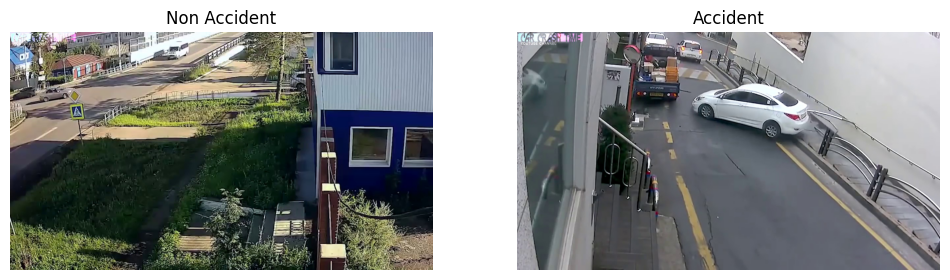

In [21]:
from pandas.core.indexes import category
import matplotlib.pyplot as plt
import cv2
import os

classes = os.listdir(train_path)

plt.figure(figsize= (12,6))

for i, category in enumerate(classes):

  image_name = os.listdir(os.path.join(train_path, category))[0]

  image_path = os.path.join(train_path, category, image_name)

  img = cv2.imread(image_path)

  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



  plt.subplot(1,2,i+1)
  plt.imshow(img)
  plt.title(category)
  plt.axis('off')

plt.show()

### check the dimension and size of image befor processing for dl

In [22]:
for category in classes:

  image_name = os.listdir(os.path.join(train_path, category))[0]

  image_path = os.path.join(train_path, category, image_name)

  img = cv2.imread(image_path)

  print(category)
  print(img.shape)
  print(img.size)
  print(img.ndim)

Non Accident
(720, 1280, 3)
2764800
3
Accident
(720, 1280, 3)
2764800
3


In [23]:
for category in classes:

  image_name = os.listdir(os.path.join(train_path, category))[0]

  image_path = os.path.join(train_path, category, image_name)

  img = cv2.imread(image_path)

  print(category)
  print(img.shape)
  print(img.size)
  print(img.ndim)

Non Accident
(720, 1280, 3)
2764800
3
Accident
(720, 1280, 3)
2764800
3


## data visuvilization

to check the distribution of image in differen claas and to check the class imbalance

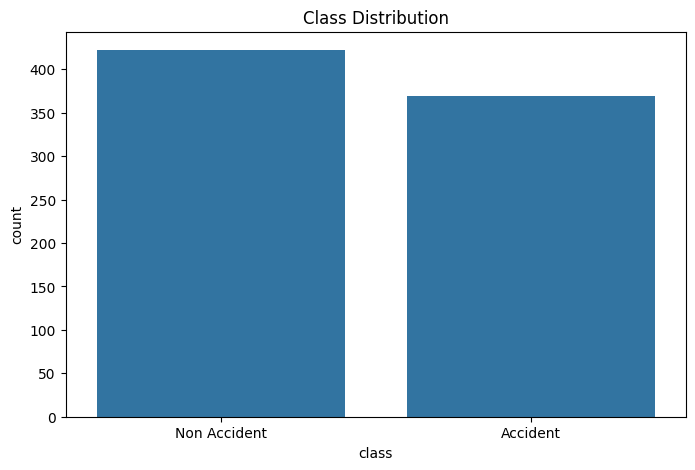

In [24]:
import seaborn as sns

class_names = []
image_counts = []

for category in classes:

  path = os.path.join(train_path, category)
  class_names.append(category)
  image_counts.append(len(os.listdir(path)))

df = pd.DataFrame({"class": class_names,
                   "count": image_counts})

plt.figure(figsize=(8,5))
sns.barplot(x='class', y='count', data=df)
plt.title('Class Distribution')
plt.show()

## check the corrupted  images

 use to check unredable image and remove , only correct/valid  image can use for data preprocesssing , use pil library for it

In [25]:
from PIL import Image
import os # Added import for os

corrupt = 0

for category in classes:

  folder_path = os.path.join(train_path, category)

  for file in os.listdir(folder_path): # Corrected typo from o.listdir to os.listdir

    try:
      img = Image.open(os.path.join(folder_path, file))
      img.verify()
    except:
      corrupt += 1 # Corrected indentation for except block

print('Corrupted images :', corrupt)

Corrupted images : 0


## import cnn libr

to build cnn , dimension reduction feature extractin  , flaattering n classification

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings

# Train generator with augumentation
train_gen_aug = ImageDataGenerator(rescale=1./255,
                               shear_range=0.2,
                               zoom_range=0.2,
                               horizontal_flip=True,
                               fill_mode='nearest')

# validation generator
val_gen_aug = ImageDataGenerator(rescale=1./255)

# Augumented Train dataset
train_ds_aug = train_gen_aug.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=True)

# validation dataset
val_ds_aug = val_gen_aug.flow_from_directory(val_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=False)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


## image preprocessing and data loading

image data generator  use to data preproceesing  t convert / rescaling img da ta 0-255 to 0-1, flow fro dir used to tl load the data training and preprocessi ng and cnn model training

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=True)

val_ds = val_gen.flow_from_directory(val_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=False)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


## apply data augumentation for reshsping  and load datase

, fliping, shifting , zooming are appli,led for generate image variation to improve model generalization

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings

# Train generator with augumentation
train_gen_aug = ImageDataGenerator(rescale=1./255,
                               shear_range=0.2,
                               zoom_range=0.2,
                               horizontal_flip=True,
                               fill_mode='nearest')

# validation generator
val_gen_aug = ImageDataGenerator(rescale=1./255)

# Augumented Train dataset
train_ds_aug = train_gen_aug.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=True)

# validation dataset

val_ds_aug = val_gen_aug.flow_from_directory(val_path, target_size=(224,224), batch_size=32, class_mode='binary',shuffle=False)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


## cnn model arcchitecture

create accidental detecction cctv image

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## model compilation

using adam optimizer, binary crossentropy, metric accuracy

In [30]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## model  training
cnn model is used to training dataset and evaluate dataset

In [31]:
history=model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 521ms/step - accuracy: 0.5322 - loss: 0.7759 - val_accuracy: 0.5408 - val_loss: 0.6875
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.5967 - loss: 0.6671 - val_accuracy: 0.6531 - val_loss: 0.6421
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.6612 - loss: 0.6253 - val_accuracy: 0.7449 - val_loss: 0.5950
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.7092 - loss: 0.5764 - val_accuracy: 0.7449 - val_loss: 0.5079
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 283ms/step - accuracy: 0.7598 - loss: 0.4999 - val_accuracy: 0.7959 - val_loss: 0.4300
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.7800 - loss: 0.4263 - val_accuracy: 0.8469 - val_loss: 0.3538
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.8357 - loss: 0.3649 - val_accuracy: 0.8673 - val_loss: 0.3432
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.8647 - loss: 0.3354 - val_accuracy: 0

## accuracy visuvilization  train / val

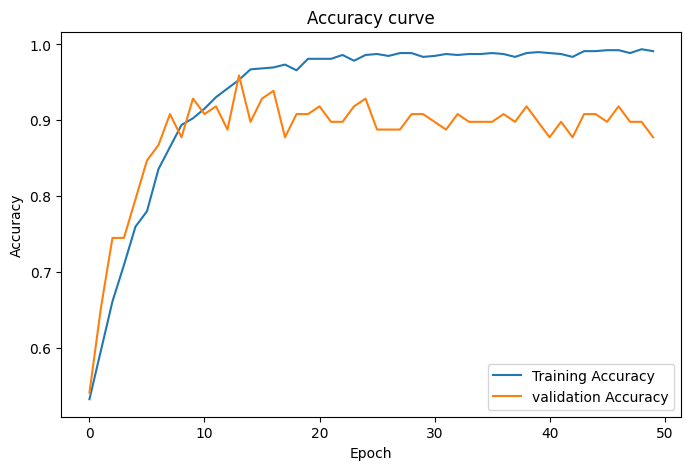

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.title('Accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## modle evaluation

check performance matrics , analyse overfitting , goodfit, underfit

In [33]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score, f1_score

# evaluate model

train_loss, train_accuracy = model.evaluate(train_ds)

test_loss, test_accuracy = model.evaluate(val_ds)

# predict on validation data
val_ds.reset()

test_pred = model.predict(val_ds)

# convert probability into 0 and 1
test_pred = (test_pred > 0.5).astype(int).ravel()

# actual labels

y_test_actual = val_ds.classes

# precision, recall, f1
precision = precision_score(y_test_actual, test_pred)
recall = recall_score(y_test_actual, test_pred)
f1 = f1_score(y_test_actual, test_pred)

## check overfitting, underfitting

diff = train_accuracy - test_accuracy

status = '' # Initialize status variable

if diff > 0.10:
  print('Overfitting')
  status = 'Overfitting'
elif diff < -0.05:
  print('Underfitting')
  status = 'Underfitting'
else:
  print('Good fit')
  status = 'Good fit'


  # create result dataframe
result_cnn = pd.DataFrame({'model': ['simple cnn'],

        'train_accuracy': [round(train_accuracy,4)],
        'test_accuracy': [round(test_accuracy,4)],
        'precision': [round(precision,4)],
        'recall': [round(recall,4)],
        'f1 score': [round(f1,4)],
         'status': [status]
        })

# display result

result_cnn

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - accuracy: 0.9937 - loss: 0.0224
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.8776 - loss: 0.3263
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step
Overfitting


,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
0,simple cnn,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting


## confussion matrix and classification report

to mesure model performance

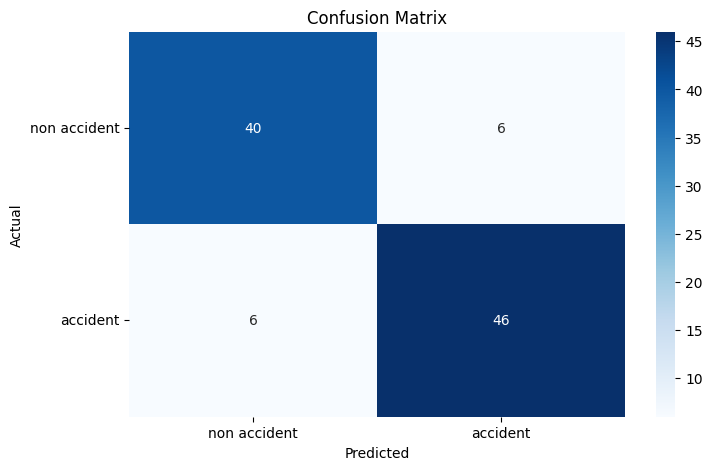

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        46
           1       0.88      0.88      0.88        52

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98



In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test_actual, test_pred)
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xticks([0.5, 1.5], ['non accident', 'accident']) # Adjusted positions for heatmap cells
plt.yticks([0.5, 1.5], ['non accident', 'accident'], rotation=0) # Adjusted positions for heatmap cells and rotation for readability
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test_actual, test_pred))

## model saving in keras for reusing in prediction and deployment

In [35]:
# save model
model.save('cnn_model.keras')

print('Model saved successfully')

Model saved successfully


## model download from collabe for deployment

In [36]:
from google.colab import files

files.download('cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## download saving the model in h5 formate withour retrining

In [37]:
model.save('cnn_model.h5')

In [38]:
from google.colab import files

files.download('cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## early stopping model checkpoint
to prevent overfiting, early stopping,and for best performance model

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_cnn_model.keras', monitor='val_loss', save_best_only=True, mode='min')

history=model.fit(train_ds, epochs=50, validation_data=val_ds,callbacks=[early_stop,checkpoint])

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.9886 - loss: 0.0291 - val_accuracy: 0.8980 - val_loss: 0.3524
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9949 - loss: 0.0222 - val_accuracy: 0.8776 - val_loss: 0.3464
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.9924 - loss: 0.0350 - val_accuracy: 0.8776 - val_loss: 0.3757
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.9924 - loss: 0.0190 - val_accuracy: 0.8980 - val_loss: 0.4382
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.9949 - loss: 0.0117 - val_accuracy: 0.8980 - val_loss: 0.4771
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.9924 - loss: 0.0147 - val_accuracy: 0.8878 - val_loss: 0.4187
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.9937 - loss: 0.0173 - val_accuracy: 0.8776 - val_loss: 0.4220


## training and validate the accuracy curve again after this

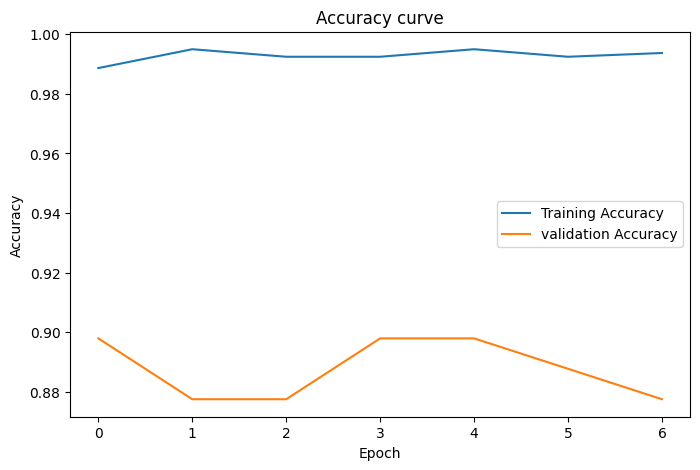

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.title('Accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## cnn model evaluation  with early stopping

In [41]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score, f1_score

# evaluate model

train_loss, train_accuracy = model.evaluate(train_ds)

test_loss, test_accuracy = model.evaluate(val_ds)

# predict on validation data
val_ds.reset()

test_pred = model.predict(val_ds)

#convert probability into 0-1
test_pred = (test_pred > 0.5).astype(int).ravel()

# actual labels
y_test_actual = val_ds.classes

# precision, recall, f1
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# check overfitting/underfitting

diff = train_accuracy - test_accuracy

status = '' # Initialize status variable

if diff > 0.10:
  print('Overfitting')
  status = 'Overfitting'
elif diff < -0.05:
  print('Underfitting')
  status = 'Underfitting'
else:
  print('Good fit')
  status = 'Good fit'

# create  result dataframe
result_cnn_early = pd.DataFrame({'model': ['simple cnn with early stopping'],
                  'train_accuracy': [round(train_accuracy,4)],
                  'test_accuracy': [round(test_accuracy,4)],
                  'precision': [round(precision,4)],
                  'recall': [round(recall,4)],
                  'f1 score': [round(f1,4)],'status': [status]
                  })
# display result
result_cnn_early

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9937 - loss: 0.0203
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.8776 - loss: 0.3464
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step
Overfitting


,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
0,simple cnn with early stopping,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting


## saving and downloading the model

In [42]:
model.save('cnn_model_early.keras')
print('cnn_model_early Model saved successfully')

cnn_model_early Model saved successfully


In [43]:
# download cnn colab

files.download('cnn_model_early.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## confusion matrix and classification report

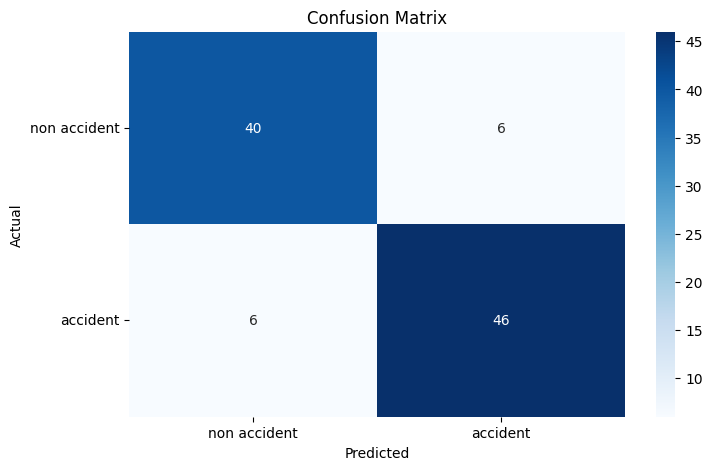

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        46
           1       0.88      0.88      0.88        52

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98



In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test_actual, test_pred)
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non accident', 'accident'],
            yticklabels=['non accident', 'accident'])

plt.xticks([0.5, 1.5], ['non accident', 'accident'])
plt.yticks([0.5, 1.5], ['non accident', 'accident'], rotation=0)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

 # classification report

print(classification_report(y_test_actual, test_pred))

## Build and train VGG16 transfer learning model

this step implement tranfer learning by using pretrained model vgg16 model with imagenet weight.this model compile use with adam optimizer

In [45]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load the pre-trained VGG16  base model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the vgg layers in the base model

vgg_base.trainable = False

# Create a new model
model_vgg16 = Sequential([vgg_base,Flatten(), Dense(128, activation='relu'), Dense(1, activation='sigmoid')])

# Compile the model
model_vgg16.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# callbacks to monitor and control model training

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_vgg16_model.keras', monitor='val_loss', save_best_only=True, mode='min')

# train model

history_vgg16 = model_vgg16.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stop, checkpoint])

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 958ms/step - accuracy: 0.5765 - loss: 1.0940 - val_accuracy: 0.7143 - val_loss: 0.5243
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - accuracy: 0.7446 - loss: 0.5054 - val_accuracy: 0.7755 - val_loss: 0.4659
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 0.7977 - loss: 0.4234 - val_accuracy: 0.8469 - val_loss: 0.3805
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - accuracy: 0.8673 - loss: 0.3375 - val_accuracy: 0.9082 - val_loss: 0.2852
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 307ms/step - accuracy: 0.9077 - loss: 0.2785 - val_accuracy: 0.9082 - val_loss: 0.2457
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.9330 - loss: 0.2283 - val_accuracy: 0.8571 - val_loss: 0.3184
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.9279 - loss: 0.2135 - val_accuracy: 0.9082 - val_loss: 0.2112
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.9355 - loss: 0.1767 - val_accuracy: 0

## visualization and model accuracy performance

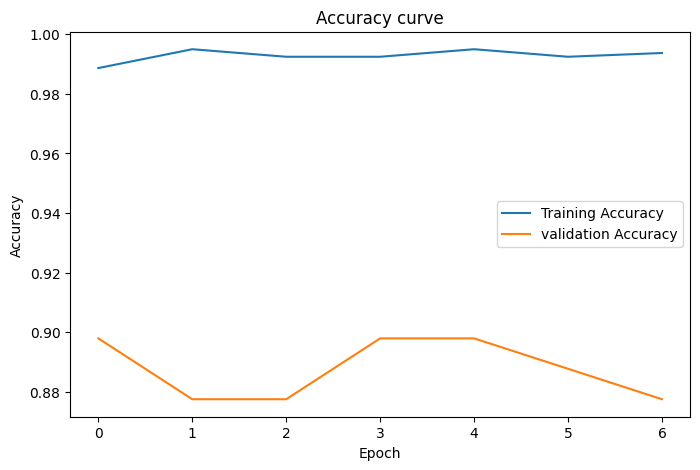

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')

plt.title('Accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## evaluate vgg16 model performance

check performance matrx  pr r f1 etc

In [47]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score, f1_score

# evaluate model

train_loss, train_accuracy = model_vgg16.evaluate(train_ds)

test_loss, test_accuracy = model_vgg16.evaluate(val_ds)

# predict on validation data
val_ds.reset()

test_pred = model_vgg16.predict(val_ds)

# convert probability into 0-1

test_pred = (test_pred > 0.5).astype(int).ravel()

# actual labels

y_test_actual = val_ds.classes

# precision, recall, f1
precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# check overfitting/underfitting

diff = train_accuracy - test_accuracy

status = '' # Initialize status variable

if diff > 0.10:
  print('Overfitting')
  status = 'Overfitting'
elif diff < -0.05:
  print('underfitting')
  status = 'Underfitting'
else:
  print('Good fit')
  status = 'Good fit'

  # create  result dataframe
result_model_vgg16 = pd.DataFrame({'model': ['vgg16'],
                  'train_accuracy': [round(train_accuracy,4)],
                  'test_accuracy': [round(test_accuracy,4)],
                  'precision': [round(precision,4)],
                  'recall': [round(recall,4)],
                  'f1 score': [round(f1,4)],'status': [status]
                  })
# display result
result_model_vgg16

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.9912 - loss: 0.0589
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.9490 - loss: 0.1393
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step
Good fit


,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
0,vgg16,0.9912,0.949,0.9608,0.9423,0.9515,Good fit


## save the trained vgg16 model

dl model in keras formate for deployment and prediction

In [48]:
model_vgg16.save('model_vgg16.keras')
print('CNN Accident detection model saved successfully')

CNN Accident detection model saved successfully


## download the train model in local system from colab

In [49]:
files.download('model_vgg16.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## generate confusion matrix and classification reports

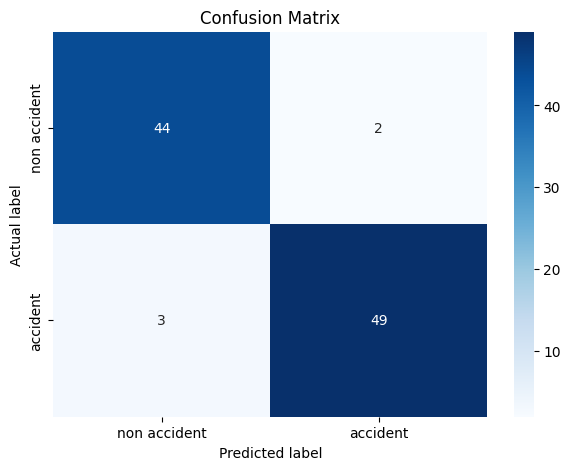

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        46
           1       0.96      0.94      0.95        52

    accuracy                           0.95        98
   macro avg       0.95      0.95      0.95        98
weighted avg       0.95      0.95      0.95        98



In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test_actual, test_pred)
plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non accident', 'accident'],
            yticklabels=['non accident', 'accident'])

plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test_actual, test_pred))



## build and Train vgg16 with data augmentation

In [51]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load the base VGG16 model

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze VGG16 layers

vgg_base.trainable = False

# Create/ build new model by use of pretrained model

model_vgg16_aug = Sequential([vgg_base, Flatten(), Dense(128, activation='relu'), Dense(1, activation='sigmoid')])


# compile mode

model_vgg16_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# callbacks to monitor and control model training

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_vgg16_model_aug.keras', monitor='val_loss', save_best_only=True, mode='min')

# train model

history_vgg16_aug = model_vgg16_aug.fit(train_ds_aug, epochs=50, validation_data=val_ds_aug, callbacks=[early_stop, checkpoint])

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 726ms/step - accuracy: 0.5563 - loss: 1.1371 - val_accuracy: 0.6735 - val_loss: 0.5795
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.7042 - loss: 0.5649 - val_accuracy: 0.7959 - val_loss: 0.4537
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 619ms/step - accuracy: 0.7472 - loss: 0.5139 - val_accuracy: 0.7551 - val_loss: 0.5143
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 636ms/step - accuracy: 0.7484 - loss: 0.5065 - val_accuracy: 0.8367 - val_loss: 0.3705
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 635ms/step - accuracy: 0.8015 - loss: 0.4054 - val_accuracy: 0.8469 - val_loss: 0.3581
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 641ms/step - accuracy: 0.8281 - loss: 0.3811 - val_accuracy: 0.8469 - val_loss: 0.3114
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.8293 - loss: 0.3722 - val_accuracy: 0.8878 - val_loss: 0.2988
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 629ms/step - accuracy: 0.8382 - loss: 0.3527 - val_accu

## visualize model accuracy performance

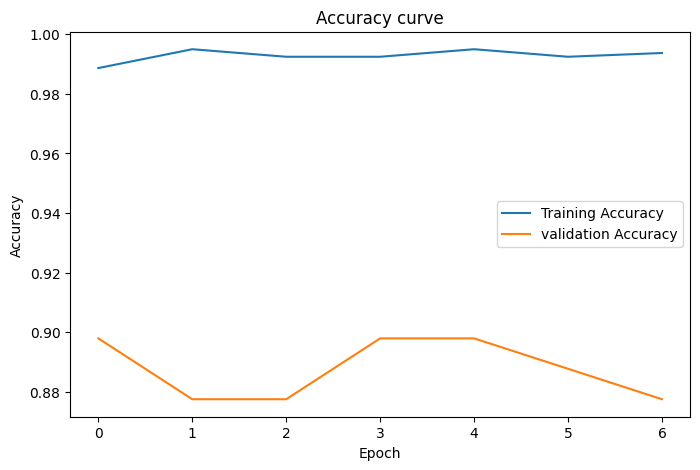

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')

plt.title('Accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## evaluate vgg16 model with data augumentation by pr r f1

In [68]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score, f1_score

# evaluate model

train_loss, train_accuracy = model_vgg16_aug.evaluate(train_ds_aug)

test_loss, test_accuracy = model_vgg16_aug.evaluate(val_ds_aug)

# predict on validation data
val_ds_aug.reset()

test_pred = model_vgg16_aug.predict(val_ds_aug)

# convert probability into 0-1

test_pred = (test_pred > 0.5).astype(int).ravel()

# actual labels

y_test_actual = val_ds_aug.classes

# precision recall, f1

precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# check overfitting/underfitting

diff = train_accuracy - test_accuracy



if diff > 0.10:
  print('Overfitting')
  status = 'Overfitting'
elif diff < -0.05:
  print('underfitting')
  status = 'Underfitting'
else:
  print('Good fit')
  status = 'Good fit'

  # create result dataframe

  result_model_vgg16_aug = pd.DataFrame({'model': ['vgg16 with data augumentation'],
  'train_accuracy': [round(train_accuracy, 4)],
  'test_accuracy' : [round(test_accuracy, 4)],
                                         'precision': [round(precision, 4)],
  'recall': [round(recall, 4)],
  'f1 score': [round(f1, 4)],
  'status': [status]
  })




# display result

result_model_vgg16_aug

25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step - accuracy: 0.9684 - loss: 0.1153
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.9286 - loss: 0.1525
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step
Good fit


,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
0,vgg16 with data augumentation,0.9684,0.9286,0.9412,0.9231,0.932,Good fit


## save the train model vgg16_aug

In [54]:
model.save('model_vgg16_aug.keras')
print('CNN Accident detection model saved successfully')

CNN Accident detection model saved successfully


In [55]:
# download  aug model
files.download('model_vgg16_aug.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## generate confusion matrix

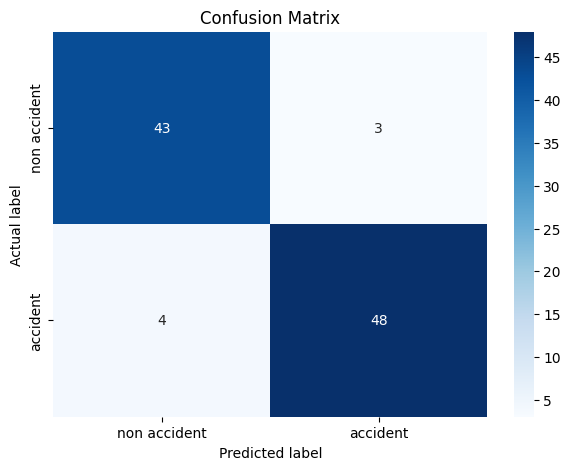

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        46
           1       0.94      0.92      0.93        52

    accuracy                           0.93        98
   macro avg       0.93      0.93      0.93        98
weighted avg       0.93      0.93      0.93        98



In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test_actual, test_pred)
plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non accident', 'accident'],
            yticklabels=['non accident', 'accident'])

plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_test_actual, test_pred))

## fine tuned vgg model with data augumentation

In [57]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load the base VGG16 model with pre-trained ImageNet weights
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Make the VGG16 base trainable for fine-tuning
vgg_base.trainable = True

# Build the fine-tuned model
model_vgg16_aug_tune = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # Assuming binary classification
])

# Compile the model with a lower learning rate for fine-tuning
model_vgg16_aug_tune.compile(optimizer=Adam(learning_rate=0.00001), # Use a very low learning rate for fine-tuning
                             loss='binary_crossentropy',
                             metrics=['accuracy'])

# Define callbacks for early stopping and model checkpointing
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_vgg16_finetune_data_aug.keras', monitor='val_loss', save_best_only=True, mode='min')

# Train the fine-tuned model using augmented data
print("Starting training for fine-tuned VGG16 with data augmentation...")
history_vgg16_finetune_aug = model_vgg16_aug_tune.fit(
    train_ds_aug,
    epochs=50, # Set a reasonable number of epochs
    validation_data=val_ds_aug,
    callbacks=[early_stop, checkpoint]
)
print("Training completed.")

Starting training for fine-tuned VGG16 with data augmentation...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6144 - loss: 0.6591 - val_accuracy: 0.7041 - val_loss: 0.5602
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 812ms/step - accuracy: 0.7193 - loss: 0.5514 - val_accuracy: 0.7653 - val_loss: 0.5035
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 782ms/step - accuracy: 0.7623 - loss: 0.4791 - val_accuracy: 0.7755 - val_loss: 0.4356
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 807ms/step - accuracy: 0.8053 - loss: 0.4313 - val_accuracy: 0.9082 - val_loss: 0.2993
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 785ms/step - accuracy: 0.8685 - loss: 0.3289 - val_accuracy: 0.8980 - val_loss: 0.2546
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 801ms/step - accuracy: 0.8736 - loss: 0.3021 - val_accuracy: 0.9388 - val_loss: 0.2271
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 801ms/step - accuracy: 0.9153 - loss: 0.2432 - val_accuracy: 0.9082 - val_loss: 0.1949
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━

## visuvilise fine tune model accuracy

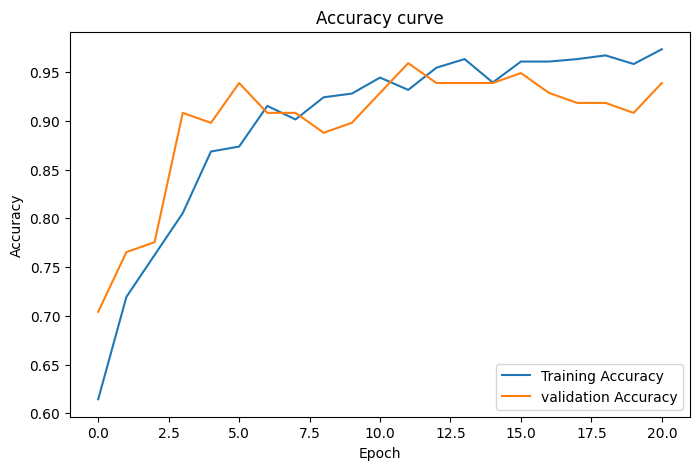

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_vgg16_finetune_aug.history['accuracy'],label='Training Accuracy')
plt.plot(history_vgg16_finetune_aug.history['val_accuracy'],label='validation Accuracy')

plt.title('Accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## evalaute fine tuned vgg16 model with data augumentation , on taining an d validation dta set and calculte ithe important evaluation metric as pr, re, f1, then check the diiference between training and testing accuracy by train and test dataset ,and finly check difference beteen  them either over undr, or good fit

chech its pr, re, fe, overfitting

In [69]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score, f1_score

# evaluate model

train_loss, train_accuracy = model_vgg16_aug_tune.evaluate(train_ds_aug)

test_loss, test_accuracy = model_vgg16_aug_tune.evaluate(val_ds_aug)

# predict on validation data
val_ds_aug.reset()

test_pred = model_vgg16_aug_tune.predict(val_ds_aug)

# convert probability into 0-1

test_pred = (test_pred > 0.5).astype(int).ravel()

# actual label using clasess

y_test_actual = val_ds_aug.classes

# precision, recall, f1

precision = precision_score(y_test_actual, test_pred)

recall = recall_score(y_test_actual, test_pred)

f1 = f1_score(y_test_actual, test_pred)

# check overfitting/underfitting

diff = train_accuracy - test_accuracy



if diff > 0.10:
  print('Overfitting')
  status = 'Overfitting'
elif diff < -0.05:
  print('underfitting')
  status = 'Underfitting'
else:
  print('Good fit')
  status = 'Good fit'

  # create resullt data frame

  result_vgg16_aug_tune = pd.DataFrame({'model': ['vgg16 with data augumentation-fine tunning'],
  'train_accuracy': [round(train_accuracy, 4)],
  'test_accuracy' : [round(test_accuracy, 4)],
  'precision' : [round(precision, 4)],
  'recall' : [round(recall, 4)],
   'f1 score' : [round(f1, 4)] ,
    'status' : [status]})

  #display result
  result_vgg16_aug_tune

25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 634ms/step - accuracy: 0.9772 - loss: 0.0820
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.9490 - loss: 0.1229
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
Good fit


In [62]:
result_vgg16_aug_tune

,model,train accuracy,test accuracy,precision,recall,f1 score,status
0,vgg16 with data augumentation-fine tunning,0.9772,0.949,0.9796,0.9231,0.9505,Good fit


In [64]:
# save the model
model_vgg16_aug_tune.save('model_vgg16_aug_fine_tune.keras')
print('Fine-tuned VGG16 model with data augmentation saved successfully')

Fine-tuned VGG16 model with data augmentation saved successfully


In [65]:
# download the model
from google.colab import files

files.download('model_vgg16_aug_fine_tune.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## generate confusion matrix and classification for fine tunnd model

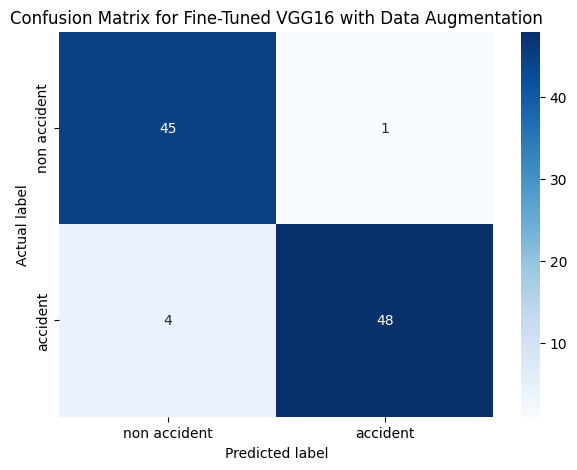

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        46
           1       0.98      0.92      0.95        52

    accuracy                           0.95        98
   macro avg       0.95      0.95      0.95        98
weighted avg       0.95      0.95      0.95        98



In [66]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test_actual, test_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non accident', 'accident'],
            yticklabels=['non accident', 'accident'])
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion Matrix for Fine-Tuned VGG16 with Data Augmentation')
plt.show()

# Classification report
print(classification_report(y_test_actual, test_pred))

## combine the all model performance, comparisionanalysis result result in single daatframe

In [70]:
import pandas as pd

# Combine all result DataFrames into a single DataFrame
all_model_results = pd.concat([
    result_cnn,
    result_cnn_early,
    result_model_vgg16,
    result_model_vgg16_aug,
    result_vgg16_aug_tune
], ignore_index=True)

# Display the combined DataFrame
all_model_results

,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
0,simple cnn,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting
1,simple cnn with early stopping,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting
2,vgg16,0.9912,0.9490,0.9608,0.9423,0.9515,Good fit
3,vgg16 with data augumentation,0.9684,0.9286,0.9412,0.9231,0.9320,Good fit
4,vgg16 with data augumentation-fine tunning,0.9772,0.9490,0.9796,0.9231,0.9505,Good fit


# short the model based on performance

In [72]:
# Sort the models based on performance (test_accuracy and f1 score)
sorted_model_results = all_model_results.sort_values(by=['test_accuracy', 'f1 score'], ascending=[False, False])

# Display the sorted DataFrame
display(sorted_model_results)

,model,train_accuracy,test_accuracy,precision,recall,f1 score,status
2,vgg16,0.9912,0.9490,0.9608,0.9423,0.9515,Good fit
4,vgg16 with data augumentation-fine tunning,0.9772,0.9490,0.9796,0.9231,0.9505,Good fit
3,vgg16 with data augumentation,0.9684,0.9286,0.9412,0.9231,0.9320,Good fit
0,simple cnn,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting
1,simple cnn with early stopping,0.9937,0.8776,0.8846,0.8846,0.8846,Overfitting


## saving the scaler object

no require here , it use only in tabular data

## create requirements.txt file

In [20]:
%%writefile requirements.txt
numpy
pandas
tensorflow
matplotlib
opencv-python
Pillow
seaborn
scikit-learn

Overwriting requirements.txt


In [21]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## create app.py file for model vgg16

In [22]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# --------------------------------------------------
# Load trained fine-tuned VGG16 model
# --------------------------------------------------

model = tf.keras.models.load_model(
    "model_vgg16_aug_fine_tune.keras"
)

# Image size used during training
IMG_HEIGHT = 224
IMG_WIDTH = 224


# --------------------------------------------------
# Streamlit App
# --------------------------------------------------

st.set_page_config(
    page_title="Accident Detection",
    page_icon="🚗"
)

st.title("🚗 Accident Detection from CCTV Image")

st.write(
    "Upload a CCTV image to detect whether it contains "
    "an Accident or Non Accident."
)


# --------------------------------------------------
# Upload Image
# --------------------------------------------------

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)


if uploaded_file is not None:

    # Open uploaded image
    img = Image.open(uploaded_file).convert("RGB")

    # Display original image
    st.image(
        img,
        caption="Uploaded Image",
        use_container_width=True
    )


    # --------------------------------------------------
    # Preprocessing
    # Same preprocessing used during training
    # --------------------------------------------------

    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Training used rescale=1./255
    img_array = img_array / 255.0


    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    prediction = model.predict(img_array, verbose=0)

    probability = float(prediction[0][0])


    # --------------------------------------------------
    # IMPORTANT:
    #
    # flow_from_directory() assigns:
    #
    # 0 = Accident
    # 1 = Non Accident
    #
    # Therefore:
    #
    # probability >= 0.5 → Non Accident
    # probability <  0.5 → Accident
    # --------------------------------------------------

    if probability >= 0.5:

        predicted_class = "Non Accident"
        confidence = probability

    else:

        predicted_class = "Accident"
        confidence = 1 - probability


    # --------------------------------------------------
    # Display Result
    # --------------------------------------------------

    st.subheader("Prediction")

    if predicted_class == "Accident":

        st.error("🚨 Accident Detected")

    else:

        st.success("✅ Non Accident")


    st.write(
        f"**Confidence:** {confidence:.2%}"
    )

    st.write(
        f"**Raw model output:** {probability:.4f}"
    )

Overwriting app.py


In [23]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# --------------------------------------------------
# Load trained fine-tuned VGG16 model
# --------------------------------------------------

model = tf.keras.models.load_model(
    "model_vgg16_aug_fine_tune.keras"
)

# Image size used during training
IMG_HEIGHT = 224
IMG_WIDTH = 224


# --------------------------------------------------
# Streamlit App
# --------------------------------------------------

st.set_page_config(
    page_title="Accident Detection",
    page_icon="🚗"
)

st.title("🚗 Accident Detection from CCTV Image")

st.write(
    "Upload a CCTV image to detect whether it contains "
    "an Accident or Non Accident."
)


# --------------------------------------------------
# Upload Image
# --------------------------------------------------

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)


if uploaded_file is not None:

    # Open uploaded image
    img = Image.open(uploaded_file).convert("RGB")

    # Display original image
    st.image(
        img,
        caption="Uploaded Image",
        use_container_width=True
    )


    # --------------------------------------------------
    # Preprocessing
    # Same preprocessing used during training
    # --------------------------------------------------

    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Training used rescale=1./255
    img_array = img_array / 255.0


    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    prediction = model.predict(img_array, verbose=0)

    probability = float(prediction[0][0])


    # --------------------------------------------------
    # IMPORTANT:
    #
    # flow_from_directory() assigns:
    #
    # 0 = Accident
    # 1 = Non Accident
    #
    # Therefore:
    #
    # probability >= 0.5 → Non Accident
    # probability <  0.5 → Accident
    # --------------------------------------------------

    if probability >= 0.5:

        predicted_class = "Non Accident"
        confidence = probability

    else:

        predicted_class = "Accident"
        confidence = 1 - probability


    # --------------------------------------------------
    # Display Result
    # --------------------------------------------------

    st.subheader("Prediction")

    if predicted_class == "Accident":

        st.error("🚨 Accident Detected")

    else:

        st.success("✅ Non Accident")


    st.write(
        f"**Confidence:** {confidence:.2%}"
    )

    st.write(
        f"**Raw model output:** {probability:.4f}"
    )

Overwriting app.py


## download updated app.py

In [25]:
# download the updated app.py
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## run on streamlit

Overwriting streamlit_app.py


In [9]:
from google.colab import files
files.download('streamlit_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
%%writefile streamlit_app.py

import streamlit as st
import requests


# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Accident Detection from CCTV Footage",
    page_icon="🚗",
    layout="centered"
)


# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("🚗 Accident Detection from CCTV Footage")

st.write(
    "Upload a CCTV image to predict whether it contains "
    "an Accident or Non Accident."
)


# --------------------------------------------------
# Flask API URL
# --------------------------------------------------

FLASK_API_URL = "http://127.0.0.1:5000/predict"


# --------------------------------------------------
# Upload Image
# --------------------------------------------------

uploaded_file = st.file_uploader(
    "Choose an image...",
    type=["jpg", "jpeg", "png"]
)


# --------------------------------------------------
# Prediction
# --------------------------------------------------

if uploaded_file is not None:

    # Display uploaded image
    st.image(
        uploaded_file,
        caption="Uploaded Image",
        use_container_width=True
    )

    st.write("")

    # Predict button
    if st.button("🔍 Detect Accident"):

        with st.spinner("Analyzing image..."):

            try:

                # Reset file position
                uploaded_file.seek(0)

                # Send image to Flask API
                files = {
                    "file": (
                        uploaded_file.name,
                        uploaded_file.getvalue(),
                        uploaded_file.type
                    )
                }

                response = requests.post(
                    FLASK_API_URL,
                    files=files,
                    timeout=60
                )


                # --------------------------------------------------
                # Successful response
                # --------------------------------------------------

                if response.status_code == 200:

                    prediction_data = response.json()

                    predicted_class = prediction_data.get(
                        "predicted_class",
                        "Unknown"
                    )

                    confidence = float(
                        prediction_data.get(
                            "confidence",
                            0
                        )
                    )


                    st.subheader("Prediction")


                    # Accident
                    if predicted_class.lower() == "accident":

                        st.error(
                            f"🚨 Accident Detected"
                        )

                    # Non Accident
                    elif predicted_class.lower() == "non accident":

                        st.success(
                            f"✅ Non Accident"
                        )

                    # Unknown
                    else:

                        st.warning(
                            f"Prediction: {predicted_class}"
                        )


                    # Confidence
                    st.info(
                        f"Confidence: {confidence:.2%}"
                    )


                # --------------------------------------------------
                # API Error
                # --------------------------------------------------

                else:

                    try:
                        error_message = response.json().get(
                            "error",
                            "Unknown API error"
                        )
                    except Exception:
                        error_message = response.text

                    st.error(
                        f"❌ API Error: {error_message}"
                    )


            # --------------------------------------------------
            # Flask connection error
            # --------------------------------------------------

            except requests.exceptions.ConnectionError:

                st.error(
                    "❌ Could not connect to Flask API."
                )

                st.info(
                    "Please start the Flask API first:"
                )

                st.code(
                    "python app.py"
                )


            # --------------------------------------------------
            # Timeout error
            # --------------------------------------------------

            except requests.exceptions.Timeout:

                st.error(
                    "⏳ Request timed out. "
                    "Please check whether the Flask API is running correctly."
                )


            # --------------------------------------------------
            # Other errors
            # --------------------------------------------------

            except Exception as e:

                st.error(
                    f"❌ Unexpected error: {e}"
                )


# --------------------------------------------------
# Instructions
# --------------------------------------------------

st.markdown("---")

st.markdown(
    """
### How to Run Locally

**1. Keep these files in the same folder:**

```text
project_folder/
│
├── app.py
├── streamlit_app.py
└── model_vgg16_aug_fine_tune.keras

Overwriting streamlit_app.py


In [6]:
pip install streamlit tensorflow numpy pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 62.5 MB/s eta 0:00:00


In [ ]:

!streamlit run streamlit_app.py



2026-09-05 00:46:33.730 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.82.244:8501



## d)	Explain the role of padding and stride in convolutional layers? How will you decide when to use the padding.

### The Role of Padding and Stride in Convolutional Layers

Convolutional Neural Networks (CNNs) use convolutional layers to extract features from input data, typically images. Two key parameters that control the behavior of these layers are **padding** and **stride**.

#### 1. Padding

**What it is:** Padding involves adding extra pixels (typically with zero values) around the border of the input image or feature map before applying the convolution operation. This effectively makes the input larger.

**Purpose/Role:**

*   **Preserving Spatial Dimensions (Same Padding):** Without padding, each convolution operation reduces the spatial dimensions (height and width) of the input. After several layers, the feature maps can become very small, losing valuable information near the edges of the original image. Padding allows the output feature map to have the same or similar spatial dimensions as the input, ensuring that information at the borders is not discarded.
*   **Retaining More Information:** Pixels at the edges of an image are only involved in a few convolution operations compared to pixels in the center. Padding ensures that these edge pixels contribute more to the output feature maps, preventing information loss.
*   **Stabilizing Training:** By maintaining spatial dimensions, padding can help in building deeper networks and stabilizing the training process, as it prevents the rapid reduction of feature map sizes, which could otherwise limit the effective receptive field of subsequent layers.

#### 2. Stride

**What it is:** Stride refers to the number of pixels the convolution kernel (filter) shifts over the input image or feature map. A stride of 1 means the kernel moves one pixel at a time, while a stride of 2 means it moves two pixels at a time, and so on.

**Purpose/Role:**

*   **Downsampling (Dimensionality Reduction):** The primary role of stride is to reduce the spatial dimensions of the output feature map. A larger stride results in a smaller output feature map. For example, a stride of 2 will halve the height and width of the feature map (approximately, depending on padding).
*   **Reducing Computational Cost:** By reducing the size of the feature maps, larger strides decrease the number of computations in subsequent layers and the amount of memory required, making the network more efficient.
*   **Increasing Receptive Field:** A larger stride effectively increases the receptive field of subsequent layers more quickly, meaning that each neuron in a deeper layer 'sees' a larger portion of the original input image.

### How to Decide When to Use Padding

The decision to use padding largely depends on whether you want to preserve the spatial dimensions of your feature maps or allow them to shrink. The two most common types of padding are 'valid' and 'same' (in TensorFlow/Keras).

1.  **'Valid' Padding (No Padding):**
    *   **When to use:** When you want the spatial dimensions to shrink naturally with each convolutional layer. This can be desirable in earlier layers to quickly extract higher-level features without needing to retain fine-grained spatial information, or when you are explicitly aiming for a small output feature map before flattening.
    *   **Effect:** The output feature map will always be smaller than the input feature map (unless the kernel size is 1x1).

2.  **'Same' Padding:**
    *   **When to use:** This is the most common choice in modern CNN architectures. It adds just enough padding (usually zeros) to the input so that the output feature map has the *same* spatial dimensions (height and width) as the input feature map, assuming a stride of 1.
    *   **Effect:** Maintains the spatial resolution across layers, which is crucial for tasks like image segmentation where fine-grained spatial information needs to be preserved, or simply to allow for deeper networks without the feature maps disappearing too quickly.
    *   **Consideration:** While it preserves dimensions, 'same' padding uses zero-valued pixels which don't carry actual information, potentially introducing some artificial patterns at the edges. However, this effect is generally minor in practice.


In summary, choose 'same' padding to maintain spatial resolution and prevent early information loss, especially in deeper networks. Choose 'valid' padding when you intentionally want to reduce spatial dimensions and are less concerned about edge information or when downsampling with stride is already handling the reduction effectively.

## e)	How does data augmentation help in improving CNN performance?



## ans
Data augmentation is a technique used to artificially increase the size and variety of a training dataset by making small changes to existing images, such as rotation, flipping, zooming, shifting, and changing brightness.

## It helps improve CNN performance in the following ways:

Reduces overfitting: It provides more varied training examples, so the CNN does not simply memorize the original images.

Improves generalization: The model learns to recognize important features even when images look slightly different.

Increases dataset diversity: It creates new variations from existing images without collecting additional data.

Makes the model more robust: The CNN can handle changes in image position, orientation, scale, and lighting.

Improves prediction accuracy: Because the model learns from more diverse examples, it often performs better on unseen test images.

Example:
If a CNN is trained to identify a disease from leaf images, data augmentation can rotate or flip the leaf images. The CNN then learns that the disease is present regardless of the leaf's orientation.

In simple words:

Data augmentation gives the CNN more variety of training examples, helping it learn better and make more accurate predictions on new images.